<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Resumo_Budget_vs_Actual_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Resumo do Budget vs Actual vc YTD Budget**

Nesse primemiro card HTML, eu mostro o andamento do Budget *(Orçado)*, Budget YTD, Actual *(Realizado)* e Year To Go valores e seu respectivo percentual. <br>
Cores condicionais para o Actual, para ficar fácil a leitura e um breve resumo.



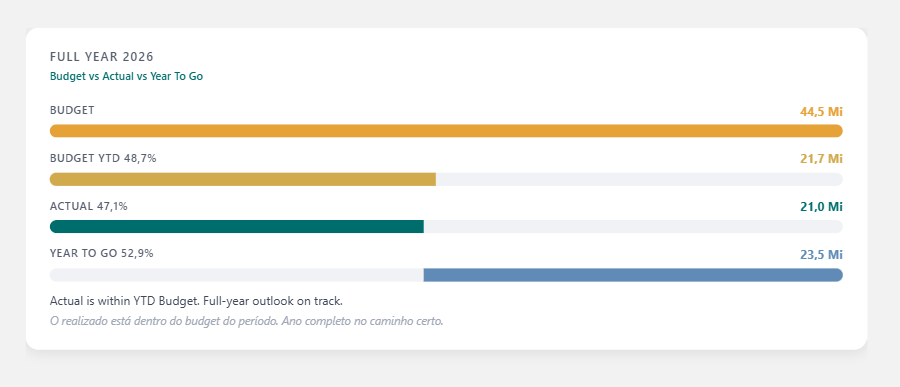

<details>
<summary>💳 HTML_Card_FullYear — clique para expandir</summary>

```dax
HTML_Card_FullYear2026 =
-- =============================================
-- VALORES ANO COMPLETO (ignora slicer)
-- =============================================

-- Atribuir as medidas para essas variáveis
VAR vActual  = [Total Realizado 2026 (Ano)]
VAR vBudget  = [Total Budget c/ Redutor (Ano)]
VAR vYTG     = [Year To Go]
VAR vBudgetYTD = [Budget 2026 YTD]

-- Percentuais sobre Budget total
VAR vPctBudgetYTD = MIN( DIVIDE( vBudgetYTD, vBudget ) * 100, 100 )
VAR vPctActual    = MIN( DIVIDE( vActual,    vBudget ) * 100, 100 )
VAR vPctYTG       = MIN( DIVIDE( vYTG,       vBudget ) * 100, 100 )

-- Largura CSS (ponto decimal)
VAR vLargBudgetYTD = SUBSTITUTE( FORMAT( vPctBudgetYTD, "0.0" ), ",", "." ) & "%"
VAR vLargActual    = SUBSTITUTE( FORMAT( vPctActual,    "0.0" ), ",", "." ) & "%"
VAR vLargYTG       = SUBSTITUTE( FORMAT( vPctYTG,       "0.0" ), ",", "." ) & "%"

-- Formatação valores
VAR vActualFmt    = FORMAT( vActual    / 1000000, "#,##0.0" ) & " Mi"
VAR vBudgetFmt    = FORMAT( vBudget    / 1000000, "#,##0.0" ) & " Mi"
VAR vBudgetYTDFmt = FORMAT( vBudgetYTD / 1000000, "#,##0.0" ) & " Mi"
VAR vYTGFmt       = FORMAT( vYTG       / 1000000, "#,##0.0" ) & " Mi"
VAR vPctBudgetYTDFmt = FORMAT( vPctBudgetYTD, "0.0" ) & "%"
VAR vPctActualFmt    = FORMAT( vPctActual,    "0.0" ) & "%"
VAR vPctYTGFmt       = FORMAT( vPctYTG,       "0.0" ) & "%"

-- Cores
VAR vIsRuim       = vActual > vBudgetYTD
VAR vCorActual    = IF( vIsRuim, "#C0392B", "#006D6D" )
VAR vCorSubtitulo = IF( vIsRuim, "#C0392B", "#006D6D" )
VAR vCorBudget    = "#E8A020"
VAR vCorBudgetYTD = "#D4A843"
VAR vCorYTG       = "#5B8DB8"

-- Mensagens condicionais
VAR vMsgEN = IF( vIsRuim,
    "Actual exceeds YTD Budget. Full-year outlook requires attention.",
    "Actual is within YTD Budget. Full-year outlook on track."
)
VAR vMsgPT = IF( vIsRuim,
    "O realizado supera o budget do período. O ano completo requer atenção.",
    "O realizado está dentro do budget do período. Ano completo no caminho certo."
)

RETURN
IF(
    ISBLANK( vActual ) && ISBLANK( vBudget ),
    BLANK(),

"<div style='
    font-family: Segoe UI, sans-serif;
    background: #FFFFFF;
    border-radius: 12px;
    padding: 18px 22px;
    min-width: 240px;
    box-shadow: 0 2px 12px rgba(0,0,0,0.10);
'>

  <!-- HEADER -->
  <div style='margin-bottom:16px;'>
    <div style='color:#555F6E; font-size:11px; font-weight:600; letter-spacing:1px; text-transform:uppercase;'>Full Year 2026</div>
    <div style='color:" & vCorSubtitulo & "; font-size:10px; margin-top:2px; font-weight:600;'>Budget vs Actual vs Year To Go</div>
  </div>

  <!-- BARRA BUDGET -->
  <div style='margin-bottom:11px;'>
    <div style='display:flex; justify-content:space-between; margin-bottom:4px;'>
      <span style='color:#555F6E; font-size:10px; font-weight:600; letter-spacing:0.5px;'>BUDGET</span>
      <span style='color:" & vCorBudget & "; font-size:11px; font-weight:700;'>" & vBudgetFmt & "</span>
    </div>
    <div style='background:#F0F2F5; border-radius:6px; height:12px; overflow:hidden;'>
      <div style='width:100%; height:12px; background:" & vCorBudget & "; border-radius:6px;'></div>
    </div>
  </div>

  <!-- BARRA BUDGET YTD -->
  <div style='margin-bottom:11px;'>
    <div style='display:flex; justify-content:space-between; margin-bottom:4px;'>
      <span style='color:#555F6E; font-size:10px; font-weight:600; letter-spacing:0.5px;'>BUDGET YTD " & vPctBudgetYTDFmt & "</span>
      <span style='color:" & vCorBudgetYTD & "; font-size:11px; font-weight:700;'>" & vBudgetYTDFmt & "</span>
    </div>
    <div style='background:#F0F2F5; border-radius:6px; height:12px; overflow:hidden;'>
      <div style='width:" & vLargBudgetYTD & "; height:12px; background:" & vCorBudgetYTD & "; border-radius:6px 0 0 6px;'></div>
    </div>
  </div>

  <!-- BARRA ACTUAL -->
  <div style='margin-bottom:11px;'>
    <div style='display:flex; justify-content:space-between; margin-bottom:4px;'>
      <span style='color:#555F6E; font-size:10px; font-weight:600; letter-spacing:0.5px;'>ACTUAL " & vPctActualFmt & "</span>
      <span style='color:" & vCorActual & "; font-size:11px; font-weight:700;'>" & vActualFmt & "</span>
    </div>
    <div style='background:#F0F2F5; border-radius:6px; height:12px; overflow:hidden;'>
      <div style='width:" & vLargActual & "; height:12px; background:" & vCorActual & "; border-radius:6px 0 0 6px;'></div>
    </div>
  </div>

  <!-- BARRA YEAR TO GO -->
  <div style='margin-bottom:8px;'>
    <div style='display:flex; justify-content:space-between; margin-bottom:4px;'>
      <span style='color:#555F6E; font-size:10px; font-weight:600; letter-spacing:0.5px;'>YEAR TO GO " & vPctYTGFmt & "</span>
      <span style='color:" & vCorYTG & "; font-size:11px; font-weight:700;'>" & vYTGFmt & "</span>
    </div>
    <div style='background:#F0F2F5; border-radius:6px; height:12px; overflow:hidden; display:flex; justify-content:flex-end;'>
      <div style='width:" & vLargYTG & "; height:12px; background:" & vCorYTG & "; border-radius:0 6px 6px 0;'></div>
    </div>
  </div>

  <!-- MENSAGEM EN -->
  <div style='color:#3D4A5C; font-size:11px; line-height:1.6; margin-bottom:2px;'>
    " & vMsgEN & "
  </div>

  <!-- MENSAGEM PT -->
  <div style='color:#A0AAB8; font-size:10.5px; line-height:1.6; font-style:italic;'>
    " & vMsgPT & "
  </div>

</div>"
# )
```

</details>

## **Resumo SG&A** *(Actual, Budget and Variance)*

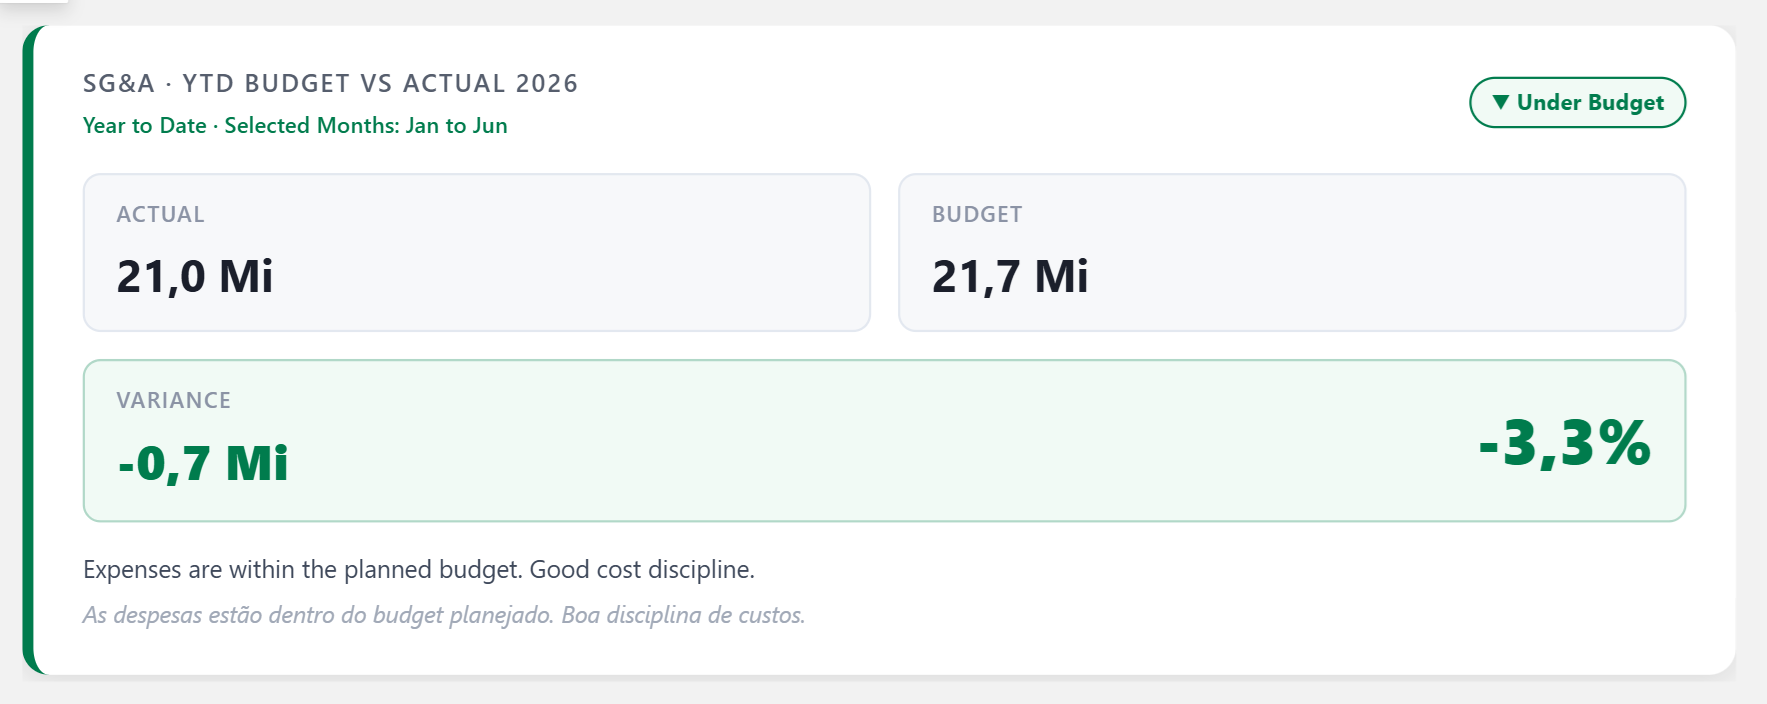

<details>
<summary>💳 HTML_Card_Desvio — clique para expandir</summary>

```dax
HTML_Card_Desvio =
-- =============================================
-- VALORES
-- =============================================
VAR vActual    = [Total Realizado 2026]
VAR vBudget    = [Total Budget c/ Redutor]
VAR vDesvio    = [Desvio 2026]
VAR vDesvioP   = [Desvio 2026 %]
VAR vPeriodo   = [Label Meses Selecionados]

-- =============================================
-- LÓGICA: no SG&A, Actual > Budget = RUIM
-- =============================================
VAR vIsRuim    = vDesvio > 0
VAR vCorDesvio = IF(vIsRuim, "#C0392B", "#1A7A4A")
VAR vCorBg     = IF(vIsRuim, "#FDF2F2", "#F2FAF5")
VAR vCorBorder = IF(vIsRuim, "#C0392B", "#1A7A4A")
VAR vIcone     = IF(vIsRuim, "▲", "▼")
VAR vLabel     = IF(vIsRuim, "Over Budget", "Under Budget")
VAR vMsgEN = IF(vIsRuim,
    "Expenses exceeded the planned budget. Cost control actions are recommended.",
    "Expenses are within the planned budget. Good cost discipline."
)
VAR vMsgPT = IF(vIsRuim,
    "As despesas ultrapassaram o budget planejado. Ações de controle de custos são recomendadas.",
    "As despesas estão dentro do budget planejado. Boa disciplina de custos."
)

-- =============================================
-- FORMATAÇÃO DOS NÚMEROS
-- =============================================
VAR vActualFmt  = FORMAT(ABS(vActual)  / 1000000, "#,##0.0") & " Mi"
VAR vBudgetFmt  = FORMAT(ABS(vBudget)  / 1000000, "#,##0.0") & " Mi"
VAR vDesvioFmt  = IF(vIsRuim, "+", "-") & FORMAT(ABS(vDesvio) / 1000000, "#,##0.0") & " Mi"
VAR vDesvioPFmt = IF(vIsRuim, "+", "-") & FORMAT(ABS(vDesvioP) * 100, "0.0") & "%"

-- =============================================
-- GUARD: sem dados, retorna BLANK
-- =============================================
RETURN
IF(
    ISBLANK(vActual) || ISBLANK(vBudget),
    BLANK(),

"<div style='
    font-family: Segoe UI, sans-serif;
    background: #FFFFFF;
    border-radius: 12px;
    padding: 18px 22px;
    min-width: 260px;
    box-shadow: 0 2px 12px rgba(0,0,0,0.10);
    border-left: 5px solid " & vCorBorder & ";
'>

  <!-- HEADER -->
  <div style='display:flex; justify-content:space-between; align-items:center; margin-bottom:14px;'>
    <div>
      <div style='color:#555F6E; font-size:11px; font-weight:600; letter-spacing:1px; text-transform:uppercase;'>SG&amp;A · YTD Budget vs Actual 2026</div>
      <div style='color:" & vCorDesvio & "; font-size:10px; margin-top:2px; font-weight:600;'>Year to Date · " & vPeriodo & "</div>
    </div>
    <span style='
      background:" & vCorBg & ";
      color:" & vCorDesvio & ";
      font-size:10px;
      font-weight:700;
      padding:3px 9px;
      border-radius:20px;
      border:1px solid " & vCorDesvio & ";
      white-space:nowrap;
      margin-left:10px;
    '>" & vIcone & " " & vLabel & "</span>
  </div>

  <!-- VALORES PRINCIPAIS -->
  <div style='display:flex; gap:12px; margin-bottom:12px;'>

    <div style='flex:1; background:#F7F8FA; border:1px solid #E2E8F0; border-radius:8px; padding:10px 14px;'>
      <div style='color:#8A94A6; font-size:10px; font-weight:600; margin-bottom:4px; letter-spacing:0.5px;'>ACTUAL</div>
      <div style='color:#1A202C; font-size:20px; font-weight:700;'>" & vActualFmt & "</div>
    </div>

    <div style='flex:1; background:#F7F8FA; border:1px solid #E2E8F0; border-radius:8px; padding:10px 14px;'>
      <div style='color:#8A94A6; font-size:10px; font-weight:600; margin-bottom:4px; letter-spacing:0.5px;'>BUDGET</div>
      <div style='color:#1A202C; font-size:20px; font-weight:700;'>" & vBudgetFmt & "</div>
    </div>

  </div>

  <!-- DESVIO -->
  <div style='
    background:" & vCorBg & ";
    border:1px solid " & vCorDesvio & "44;
    border-radius:8px;
    padding:10px 14px;
    margin-bottom:12px;
    display:flex;
    justify-content:space-between;
    align-items:center;
  '>
    <div>
      <div style='color:#8A94A6; font-size:10px; font-weight:600; margin-bottom:3px; letter-spacing:0.5px;'>VARIANCE</div>
      <div style='color:" & vCorDesvio & "; font-size:22px; font-weight:800;'>" & vDesvioFmt & "</div>
    </div>
    <div style='color:" & vCorDesvio & "; font-size:28px; font-weight:800;'>" & vDesvioPFmt & "</div>
  </div>

  <!-- MENSAGEM EN -->
  <div style='color:#3D4A5C; font-size:11px; line-height:1.6; margin-bottom:4px;'>
    " & vMsgEN & "
  </div>

  <!-- MENSAGEM PT -->
  <div style='color:#A0AAB8; font-size:10.5px; line-height:1.6; font-style:italic;'>
    " & vMsgPT & "
  </div>

</div>"
)
```

</details>